In [22]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [23]:
class BatsmanState(TypedDict):
    runs: int
    balls : int
    fours : int
    sixes : int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [24]:
def calculate_boundary_percent(state: BatsmanState):
    boundary_percent = ((state["fours"]*4+state["sixes"]*6)/state["runs"]) * 100
    return {"boundary_percent": boundary_percent}

In [25]:
def calculate_bpb(state: BatsmanState):
    bpb = state["balls"]/(state["fours"]+state["sixes"])
    return {"bpb":bpb}

In [26]:
def calculate_sr(state: BatsmanState):
    sr = (state["runs"]/state["balls"])*100
    return {"sr":sr}

In [27]:
def summary(state: BatsmanState)->BatsmanState:
    summary = f"Strike Rate: {state["sr"]}\nBpb: {state["bpb"]}\nBP:{state["boundary_percent"]}"
    return {"summary":summary}

In [28]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_boundary_percent", calculate_boundary_percent)
graph.add_node("calculate_bpb", calculate_bpb)
graph.add_node("calculate_sr", calculate_sr)
graph.add_node("summary", summary)

graph.add_edge(START, "calculate_boundary_percent")
graph.add_edge(START, "calculate_bpb")
graph.add_edge(START, "calculate_sr")
graph.add_edge("calculate_boundary_percent", "summary")
graph.add_edge("calculate_bpb", "summary")
graph.add_edge("calculate_sr", "summary")
graph.add_edge("summary", END)

workflow = graph.compile()

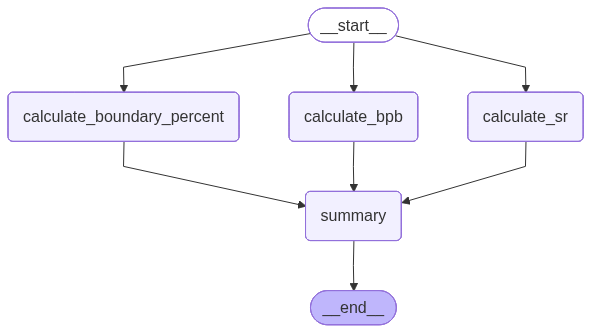

In [29]:
workflow

In [30]:
initial_state = {
    "runs" : 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4
}

final_state =workflow.invoke(initial_state)

In [31]:
final_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': 'Strike Rate: 200.0\nBpb: 5.0\nBP:48.0'}